# Objective 2 — Price Prediction Model
Train 6 models: **(LightGBM + HistGBM) × (Uber / Lyft / Combined)**

### New Features from EDA (`eda_by_cab_type.ipynb`)
| Feature | EDA Insight |
|---|---|
| `is_foggy` | Foggy is the only weather where Lyft price spikes UP while Uber goes DOWN |
| `is_low_visibility` | Both platforms show price spike at exactly visibility = 1.7 miles |
| `surge_is_round` | Lyft uses discrete surge (1.25/1.5/2.0/…) causing step-like pricing (.00/.50) |
| `tier_ordinal` | Ordinal encoding per EDA tier order: Budget→Standard→Extra Space→Premium→Premium SUV |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso, ElasticNet
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMRegressor

import optuna
import lightgbm as lgb
from optuna.integration import LightGBMPruningCallback

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

print("Imports OK")

Imports OK


## 1. Load Data & Feature Engineering (with EDA Insights)

In [3]:
df = pd.read_csv("../data/processed/rideshare_feature_engineering.csv")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
df.head(2)

Loaded: 637,976 rows × 53 cols


,hour,day,month,source,destination,cab_type,name,price,distance,surge_multiplier,...,log_distance,surge_intensity,price_per_mile,is_surge,source_avg_price,dest_avg_price,cab_type_enc,destination_enc,route_frequency,source_enc
0,9,16,12,Haymarket Square,North Station,Lyft,Shared,5.0,0.44,1.0,...,0.364643,0.0,11.337868,0,13.578114,16.805238,1,7,8874,5
1,2,27,11,Haymarket Square,North Station,Lyft,Lux,11.0,0.44,1.0,...,0.364643,0.0,24.943311,0,13.578114,16.805238,1,7,8874,5


In [ ]:
# ── [ORIGINAL] Route-based interaction features ──────────────────────────────
df['dist_x_surge_freq'] = df['distance'] * df['surge_multiplier'] / (df['route_frequency'] + 1)
df['dist_per_route']    = df['distance'] / (df['route_frequency'] + 1)
df['price_pressure']    = df['distance'] / (df['route_frequency'] + 1) * df['surge_multiplier']

# ════════════════════════════════════════════════════════════════
# [NEW — from EDA] Feature Engineering derived from eda_by_cab_type
# ════════════════════════════════════════════════════════════════

# 1. is_foggy — Foggy is the ONLY weather where Lyft price spikes UP while Uber goes DOWN
#    Dropping all weather columns would lose this signal — keep it as a binary flag
df['is_foggy'] = (df['short_summary'].str.strip().str.lower() == 'foggy').astype(int)

# 2. is_low_visibility — EDA found price spike at visibility <= 1.7 miles for both platforms
df['is_low_visibility'] = (df['visibility'] <= 1.7).astype(int)


# 4. foggy_x_lyft — interaction term: captures asymmetric fog effect (Lyft spikes, Uber doesn't)
df['is_lyft'] = (df['cab_type'] == 'Lyft').astype(int)
df['foggy_x_lyft'] = df['is_foggy'] * df['is_lyft']

print("New features from EDA:")
print(f"  is_foggy:         {df['is_foggy'].sum():,} rows ({df['is_foggy'].mean()*100:.1f}%)")
print(f"  is_low_visibility:{df['is_low_visibility'].sum():,} rows ({df['is_low_visibility'].mean()*100:.1f}%)")
print(f"  foggy_x_lyft:     {df['foggy_x_lyft'].sum():,} rows ({df['foggy_x_lyft'].mean()*100:.1f}%)")

New features from EDA:
  is_foggy:         8,292 rows (1.3%)
  is_low_visibility:10,204 rows (1.6%)
  surge_is_round:   637,976 rows (100.0%)
  foggy_x_lyft:     4,002 rows (0.6%)


In [5]:
# ── Drop weather columns (keep only features already extracted above) ────────
weather = [
    'latitude', 'longitude', 'temperature', 'apparentTemperature', 'short_summary',
    'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust',
    'visibility',  # already extracted to is_low_visibility
    'temperatureHigh', 'temperatureLow', 'apparentTemperatureHigh', 'apparentTemperatureLow',
    'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone', 'moonPhase',
    'precipIntensityMax', 'temperatureMin', 'temperatureMax',
    'apparentTemperatureMin', 'apparentTemperatureMax'
]
time         = ['hour', 'day', 'month']
data_leakage = ['source_avg_price', 'dest_avg_price', 'log_price', 'price_per_mile',
                'tier_enc', 'name_enc', 'cab_type_enc', 'destination_enc', 'source_enc']

drop_columns = weather + time + data_leakage
df = df.drop(columns=drop_columns, errors='ignore')

print(f"Columns after drop: {df.shape[1]}")
print(df.columns.tolist())

Columns after drop: 22
['source', 'destination', 'cab_type', 'name', 'price', 'distance', 'surge_multiplier', 'tier', 'route', 'surge_x_distance', 'log_distance', 'surge_intensity', 'is_surge', 'route_frequency', 'dist_x_surge_freq', 'dist_per_route', 'price_pressure', 'is_foggy', 'is_low_visibility', 'surge_is_round', 'is_lyft', 'foggy_x_lyft']


In [6]:
# ── [NEW] Tier Ordinal Encoding aligned with EDA tier_order ─────────────────
# EDA shows clear price escalation pattern across tiers
# Premium SUV shows the steepest jump — encode as true ordinal (not arbitrary)
tier_order_map = {
    'Budget':      0,
    'Standard':    1,
    'Extra Space': 2,
    'Premium':     3,
    'Premium SUV': 4,
}
df['tier_ordinal'] = df['tier'].map(tier_order_map)
print("Tier ordinal distribution:")
print(df.groupby('tier')['tier_ordinal'].first().sort_values())

Tier ordinal distribution:
tier
Premium    3.0
Economy    NaN
Mid        NaN
Name: tier_ordinal, dtype: float64


In [ ]:
# ── Feature Sets ─────────────────────────────────────────────────────────────
numeric_cols = [
    # original
    'surge_multiplier', 'surge_x_distance', 'distance',
    'log_distance', 'surge_intensity', 'is_surge',
    'route_frequency', 'dist_x_surge_freq', 'dist_per_route', 'price_pressure',
    # [NEW from EDA]
    'is_foggy', 'is_low_visibility', 'foggy_x_lyft',
    'tier_ordinal', 'route_mean_price', 'route_std_price'
]

categorical_cols = ['source', 'destination', 'cab_type', 'name', 'tier', 'route']

feature_cols = numeric_cols + categorical_cols

# ── Split by cab_type ─────────────────────────────────────────────────────────
df_uber = df[df['cab_type'] == 'Uber'].copy().reset_index(drop=True)
df_lyft = df[df['cab_type'] == 'Lyft'].copy().reset_index(drop=True)

print(f"Uber: {len(df_uber):,} | Lyft: {len(df_lyft):,} | Combined: {len(df):,}")

Uber: 330,568 | Lyft: 307,408 | Combined: 637,976


## 2. Train/Test Split & Encoding

In [ ]:
def make_split(df_sub, feature_cols, stratify_col='tier'):
    X = df_sub[feature_cols + ['route']].copy()  # keep route for merge
    y = df_sub['price'].copy()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42,
        stratify=df_sub[stratify_col]
    )

    # ── Route-level stats from TRAIN only (no leakage) ───────────────────────
    train_with_price = X_tr.copy()
    train_with_price['price'] = y_tr.values
    route_stats = train_with_price.groupby('route')['price'].agg(
        route_mean_price='mean',
        route_std_price='std'
    ).reset_index()
    route_stats['route_std_price'] = route_stats['route_std_price'].fillna(0)

    X_tr = X_tr.merge(route_stats, on='route', how='left')
    X_te = X_te.merge(route_stats, on='route', how='left')
    # fill unseen routes in test with global train mean
    global_mean = y_tr.mean()
    X_tr[['route_mean_price', 'route_std_price']] = X_tr[['route_mean_price', 'route_std_price']].fillna(global_mean)
    X_te[['route_mean_price', 'route_std_price']] = X_te[['route_mean_price', 'route_std_price']].fillna(global_mean)

    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_tr[categorical_cols] = enc.fit_transform(X_tr[categorical_cols])
    X_te[categorical_cols] = enc.transform(X_te[categorical_cols])

    return X_tr, X_te, y_tr, y_te, enc


X_tr_uber, X_te_uber, y_tr_uber, y_te_uber, enc_uber = make_split(df_uber)
X_tr_lyft, X_te_lyft, y_tr_lyft, y_te_lyft, enc_lyft = make_split(df_lyft)
X_tr_all,  X_te_all,  y_tr_all,  y_te_all,  enc_all  = make_split(df, stratify_col='cab_type')

print("Split sizes:")
for name, tr, te in [('Uber', X_tr_uber, X_te_uber),
                      ('Lyft', X_tr_lyft, X_te_lyft),
                      ('Combined', X_tr_all, X_te_all)]:
    print(f"  {name:<10} train={len(tr):,}  test={len(te):,}")

Split sizes:
  Uber       train=264,454  test=66,114
  Lyft       train=245,926  test=61,482
  Combined   train=510,380  test=127,596


## 3. Coarse Search (เพื่อหา best hyperparameter range สำหรับ Optuna)

In [ ]:
coarse_configs = [
    {
        'name': 'Lasso',
        'model': Lasso(),
        'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]}
    },
    {
        'name': 'ElasticNet',
        'model': ElasticNet(),
        'params': {
            'alpha': [0.001, 0.01, 0.1, 1, 10],
            'l1_ratio': [0.2, 0.5, 0.8]
        }
    },
    {
        'name': 'XGBoost',
        'model': XGBRegressor(n_jobs=-1, random_state=42),
        'params': {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 6, 9]
        }
    },
    {
        'name': 'HistGBM',
        'model': HistGradientBoostingRegressor(random_state=42),
        'params': {
            'max_iter': [500, 1000, 2000],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 6, 9],
            'max_leaf_nodes': [31, 63, 127],
        }
    },
    {
        'name': 'LightGBM',
        'model': LGBMRegressor(random_state=42, verbose=-1),
        'params': {
            'n_estimators': [200, 500, 1000],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'num_leaves': [31, 63, 127],
            'min_child_samples': [20, 50, 100],
        }
    },
]

datasets = {
    'Uber':     (X_tr_uber, y_tr_uber),
    'Lyft':     (X_tr_lyft, y_tr_lyft),
    'Combined': (X_tr_all,  y_tr_all),
}

coarse_results = []

for ds_name, (X_tr, y_tr) in datasets.items():
    print(f"\n{'='*55}")
    print(f"Coarse Search — {ds_name}")
    print(f"{'Model':<12} | {'CV RMSE':<10} | Best Params")

    for cfg in coarse_configs:
        search = RandomizedSearchCV(
            cfg['model'], cfg['params'],
            n_iter=10, cv=5,            # เพิ่มเป็น cv=5 (เดิม 3)
            scoring='neg_mean_squared_error',
            n_jobs=-1, random_state=42
        )
        search.fit(X_tr, y_tr)
        rmse = np.sqrt(-search.best_score_)
        coarse_results.append({
            'Dataset': ds_name, 'Model': cfg['name'],
            'RMSE': rmse, 'Best Params': search.best_params_
        })
        print(f"{cfg['name']:<12} | {rmse:<10.4f} | {search.best_params_}")

res_df = pd.DataFrame(coarse_results)
print("\n📌 Best starting point per dataset:")
print(res_df.loc[res_df.groupby('Dataset')['RMSE'].idxmin(),
                 ['Dataset','Model','RMSE']].to_string(index=False))


Coarse Search — Uber
Model        | CV RMSE    | Best Params
HistGBM      | 1.8515     | {'max_leaf_nodes': 127, 'max_iter': 1000, 'max_depth': 6, 'learning_rate': 0.2}
LightGBM     | 1.8448     | {'num_leaves': 63, 'n_estimators': 1000, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.1}

Coarse Search — Lyft
Model        | CV RMSE    | Best Params
HistGBM      | 1.2979     | {'max_leaf_nodes': 127, 'max_iter': 1000, 'max_depth': 9, 'learning_rate': 0.1}
LightGBM     | 1.3103     | {'num_leaves': 63, 'n_estimators': 1000, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.1}

Coarse Search — Combined
Model        | CV RMSE    | Best Params
HistGBM      | 1.6167     | {'max_leaf_nodes': 127, 'max_iter': 1000, 'max_depth': 9, 'learning_rate': 0.1}
LightGBM     | 1.6309     | {'num_leaves': 63, 'n_estimators': 1000, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.1}

📌 Best starting point per dataset:
 Dataset    Model     RMSE
Combined  HistGBM 1.616703


In [10]:
# Convert coarse_results list -> coarse_dict for Optuna
coarse_dict = {}
for row in coarse_results:
    ds = row['Dataset']
    if ds not in coarse_dict:
        coarse_dict[ds] = {}
    coarse_dict[ds][row['Model']] = row['Best Params']

print("coarse_dict ready")

coarse_dict ready


## 4. Optuna Fine-Tuning (Obj 2 — Maximize Prediction Accuracy)

In [ ]:
N_TRIALS = 45  # เพิ่มจาก 30 → 60 เพื่อความแม่น (ใช้เวลาประมาณ 2× แต่ RMSE ลงได้อีก)

def tune_with_optuna(X_tr, y_tr, X_te, y_te, coarse_params_dict, dataset_name, model_type='LightGBM'):
    """
    Fine-tune LightGBM or HistGBM with Optuna.
    - Uses coarse best params as starting range for search
    - Early stopping to prevent overfitting
    - Retrains on full train set with best params
    """
    c          = coarse_params_dict.get(model_type, {})
    base_lr    = c.get('learning_rate', 0.05)
    base_depth = c.get('max_depth', 6)

    # Validation set สำหรับ Optuna (แยกจาก test set)
    X_t, X_v, y_t, y_v = train_test_split(X_tr, y_tr, test_size=0.15, random_state=42)

    def objective(trial):
        if model_type == 'LightGBM':
            base_leaves = c.get('num_leaves', 63)
            base_min_ch = c.get('min_child_samples', 50)
            params = {
                'n_estimators':       5000,
                'learning_rate':      trial.suggest_float('learning_rate',
                                          max(0.005, base_lr * 0.4),
                                          min(0.3,   base_lr * 2.5), log=True),
                'num_leaves':         trial.suggest_int('num_leaves',
                                          max(15, base_leaves // 2),
                                          min(511, base_leaves * 3)),
                'max_depth':          trial.suggest_int('max_depth',
                                          max(2, base_depth - 2),
                                          min(15, base_depth + 4)),
                'min_child_samples':  trial.suggest_int('min_child_samples',
                                          max(5, base_min_ch // 2),
                                          min(200, base_min_ch * 4)),
                'subsample':          trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha':          trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
                'reg_lambda':         trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
                'min_split_gain':     trial.suggest_float('min_split_gain', 0.0, 1.0),
                'random_state': 42, 'n_jobs': -1, 'verbose': -1,
            }
            model = LGBMRegressor(**params)
            model.fit(
                X_t, y_t,
                eval_set=[(X_v, y_v)],
                eval_metric='rmse',
                callbacks=[
                    lgb.early_stopping(50, verbose=False),
                    LightGBMPruningCallback(trial, 'rmse')
                ]
            )
            trial.set_user_attr('best_iteration', model.best_iteration_)
            preds = model.predict(X_v)

        elif model_type == 'HistGBM':
            base_leaves = c.get('max_leaf_nodes', 63)
            base_min_s  = c.get('min_samples_leaf', 20)
            params = {
                'max_iter':            5000,
                'learning_rate':       trial.suggest_float('learning_rate',
                                           max(0.005, base_lr * 0.4),
                                           min(0.3,   base_lr * 2.5), log=True),
                'max_depth':           trial.suggest_int('max_depth',
                                           max(2, base_depth - 2),
                                           min(15, base_depth + 4)),
                'max_leaf_nodes':      trial.suggest_int('max_leaf_nodes',
                                           max(15, base_leaves // 2),
                                           min(511, base_leaves * 3)),
                'min_samples_leaf':    trial.suggest_int('min_samples_leaf',
                                           max(5, base_min_s // 2),
                                           min(200, base_min_s * 4)),
                'l2_regularization':   trial.suggest_float('l2_regularization', 1e-4, 10.0, log=True),
                'max_features':        trial.suggest_float('max_features', 0.5, 1.0),
                'random_state': 42,
                'early_stopping': True,
                'validation_fraction': 0.15,
                'n_iter_no_change': 50,
                'tol': 1e-5,
            }
            model = HistGradientBoostingRegressor(**params)
            model.fit(X_t, y_t)
            trial.set_user_attr('best_iteration', model.n_iter_)
            preds = model.predict(X_v)

        return np.sqrt(mean_squared_error(y_v, preds))

    print(f"\n{'='*55}")
    print(f"Optuna [{model_type}] — {dataset_name}  (N_TRIALS={N_TRIALS})")
    print(f"  base: lr={base_lr:.4f}, depth={base_depth}")

    sampler = optuna.samplers.TPESampler(seed=42)  # TPE ฉลาดกว่า random
    pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
    study   = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=N_TRIALS, timeout=900, show_progress_bar=False)

    best_p = study.best_params.copy()
    best_p['random_state'] = 42

    # Retrain บน full train set
    if model_type == 'LightGBM':
        best_p['n_estimators'] = study.best_trial.user_attrs.get('best_iteration', 500)
        best_p.update({'n_jobs': -1, 'verbose': -1})
        final_model = LGBMRegressor(**best_p)
    else:
        best_p['max_iter'] = study.best_trial.user_attrs.get('best_iteration', 500)
        for key in ['early_stopping', 'validation_fraction', 'n_iter_no_change', 'tol']:
            best_p.pop(key, None)
        final_model = HistGradientBoostingRegressor(**best_p)

    final_model.fit(X_tr, y_tr)
    y_pred = final_model.predict(X_te)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    r2     = r2_score(y_te, y_pred)
    mae    = np.mean(np.abs(y_te - y_pred))

    print(f"  val RMSE = {study.best_value:.4f}")
    print(f"  test RMSE = {rmse:.4f}  |  R² = {r2:.4f}  |  MAE = {mae:.4f}")
    return final_model, rmse, r2, mae, y_pred

## 5. Train 6 Models: (LGBM + HistGBM) × (Uber / Lyft / Combined)

In [12]:
# ── UBER ─────────────────────────────────────────────────────────────────────
model_lgbm_uber, rmse_lgbm_uber, r2_lgbm_uber, mae_lgbm_uber, pred_lgbm_uber = tune_with_optuna(
    X_tr_uber, y_tr_uber, X_te_uber, y_te_uber,
    coarse_dict['Uber'], 'Uber', model_type='LightGBM'
)
model_hist_uber, rmse_hist_uber, r2_hist_uber, mae_hist_uber, pred_hist_uber = tune_with_optuna(
    X_tr_uber, y_tr_uber, X_te_uber, y_te_uber,
    coarse_dict['Uber'], 'Uber', model_type='HistGBM'
)

model_uber = model_lgbm_uber if rmse_lgbm_uber <= rmse_hist_uber else model_hist_uber
best_uber_name = 'LightGBM' if model_uber is model_lgbm_uber else 'HistGBM'
print(f"\n✅ Best Uber: {best_uber_name}  RMSE={min(rmse_lgbm_uber, rmse_hist_uber):.4f}")


Optuna [LightGBM] — Uber  (N_TRIALS=60)
  base: lr=0.1000, depth=5
  val RMSE = 1.8447
  test RMSE = 1.8577  |  R² = 0.9527  |  MAE = 1.1356

Optuna [HistGBM] — Uber  (N_TRIALS=60)
  base: lr=0.2000, depth=6
  val RMSE = 1.8526
  test RMSE = 1.8671  |  R² = 0.9522  |  MAE = 1.1389

✅ Best Uber: LightGBM  RMSE=1.8577


In [13]:
# ── LYFT ─────────────────────────────────────────────────────────────────────
model_lgbm_lyft, rmse_lgbm_lyft, r2_lgbm_lyft, mae_lgbm_lyft, pred_lgbm_lyft = tune_with_optuna(
    X_tr_lyft, y_tr_lyft, X_te_lyft, y_te_lyft,
    coarse_dict['Lyft'], 'Lyft', model_type='LightGBM'
)
model_hist_lyft, rmse_hist_lyft, r2_hist_lyft, mae_hist_lyft, pred_hist_lyft = tune_with_optuna(
    X_tr_lyft, y_tr_lyft, X_te_lyft, y_te_lyft,
    coarse_dict['Lyft'], 'Lyft', model_type='HistGBM'
)

model_lyft = model_lgbm_lyft if rmse_lgbm_lyft <= rmse_hist_lyft else model_hist_lyft
best_lyft_name = 'LightGBM' if model_lyft is model_lgbm_lyft else 'HistGBM'
print(f"\n✅ Best Lyft: {best_lyft_name}  RMSE={min(rmse_lgbm_lyft, rmse_hist_lyft):.4f}")


Optuna [LightGBM] — Lyft  (N_TRIALS=60)
  base: lr=0.1000, depth=5
  val RMSE = 1.2936
  test RMSE = 1.2893  |  R² = 0.9834  |  MAE = 0.9127

Optuna [HistGBM] — Lyft  (N_TRIALS=60)
  base: lr=0.1000, depth=9
  val RMSE = 1.2957
  test RMSE = 1.2928  |  R² = 0.9833  |  MAE = 0.9138

✅ Best Lyft: LightGBM  RMSE=1.2893


In [ ]:
# ── COMBINED ─────────────────────────────────────────────────────────────────
model_lgbm_combined, rmse_lgbm_combined, r2_lgbm_combined, mae_lgbm_combined, pred_lgbm_combined = tune_with_optuna(
    X_tr_all, y_tr_all, X_te_all, y_te_all,
    coarse_dict['Combined'], 'Combined', model_type='LightGBM'
)
model_hist_combined, rmse_hist_combined, r2_hist_combined, mae_hist_combined, pred_hist_combined = tune_with_optuna(
    X_tr_all, y_tr_all, X_te_all, y_te_all,
    coarse_dict['Combined'], 'Combined', model_type='HistGBM'
)

model_combined = model_lgbm_combined if rmse_lgbm_combined <= rmse_hist_combined else model_hist_combined
best_combined_name = 'LightGBM' if model_combined is model_lgbm_combined else 'HistGBM'
print(f"\n✅ Best Combined: {best_combined_name}  RMSE={min(rmse_lgbm_combined, rmse_hist_combined):.4f}")


Optuna [LightGBM] — Combined  (N_TRIALS=60)
  base: lr=0.1000, depth=5
  val RMSE = 1.6326
  test RMSE = 1.5767  |  R² = 0.9713  |  MAE = 1.0213

Optuna [HistGBM] — Combined  (N_TRIALS=60)
  base: lr=0.1000, depth=9
  val RMSE = 1.6380
  test RMSE = 1.5821  |  R² = 0.9711  |  MAE = 1.0244

✅ Best Combined: LightGBM  RMSE=1.5767


ใช้ MAE ในการเปรียบเทียบเลือกตัวที่ดีที่สุด

## 6. Results Summary Table

In [15]:
summary_data = [
    {'Dataset': 'Uber',     'Model': 'LightGBM', 'RMSE': rmse_lgbm_uber,     'R²': r2_lgbm_uber,     'MAE': mae_lgbm_uber},
    {'Dataset': 'Uber',     'Model': 'HistGBM',  'RMSE': rmse_hist_uber,     'R²': r2_hist_uber,     'MAE': mae_hist_uber},
    {'Dataset': 'Lyft',     'Model': 'LightGBM', 'RMSE': rmse_lgbm_lyft,     'R²': r2_lgbm_lyft,     'MAE': mae_lgbm_lyft},
    {'Dataset': 'Lyft',     'Model': 'HistGBM',  'RMSE': rmse_hist_lyft,     'R²': r2_hist_lyft,     'MAE': mae_hist_lyft},
    {'Dataset': 'Combined', 'Model': 'LightGBM', 'RMSE': rmse_lgbm_combined, 'R²': r2_lgbm_combined, 'MAE': mae_lgbm_combined},
    {'Dataset': 'Combined', 'Model': 'HistGBM',  'RMSE': rmse_hist_combined, 'R²': r2_hist_combined, 'MAE': mae_hist_combined},
]
summary_df = pd.DataFrame(summary_data)

print(f"\n{'='*65}")
print(f"{'Dataset':<12} | {'Model':<10} | {'RMSE':>8} | {'R²':>8} | {'MAE':>8}")
print(f"{'-'*65}")
for _, row in summary_df.iterrows():
    best_mark = ' ★' if (
        (row['Dataset'] == 'Uber'     and row['Model'] == best_uber_name) or
        (row['Dataset'] == 'Lyft'     and row['Model'] == best_lyft_name) or
        (row['Dataset'] == 'Combined' and row['Model'] == best_combined_name)
    ) else ''
    print(f"{row['Dataset']:<12} | {row['Model']:<10} | {row['RMSE']:>8.4f} | {row['R²']:>8.4f} | {row['MAE']:>8.4f}{best_mark}")
print(f"{'='*65}")
print("★ = Best model for that dataset")


Dataset      | Model      |     RMSE |       R² |      MAE
-----------------------------------------------------------------
Uber         | LightGBM   |   1.8577 |   0.9527 |   1.1356 ★
Uber         | HistGBM    |   1.8671 |   0.9522 |   1.1389
Lyft         | LightGBM   |   1.2893 |   0.9834 |   0.9127 ★
Lyft         | HistGBM    |   1.2928 |   0.9833 |   0.9138
Combined     | LightGBM   |   1.5767 |   0.9713 |   1.0213 ★
Combined     | HistGBM    |   1.5821 |   0.9711 |   1.0244
★ = Best model for that dataset


## 7. Obj 2 Visualization — Residual Plot + Error Distribution
> เลือก 2 visualization ที่สำคัญที่สุด:
> 1. **Residual Plot** — เห็นว่า model พลาดตรงไหน, pattern ไหมหลัง predict
> 2. **Error Distribution** — เห็น bias, symmetry, fat-tail ของ error

In [16]:
# ── รวม model results ──────────────────────────────────────────────────────
model_results = {
    'Uber': {
        'LightGBM': {'model': model_lgbm_uber, 'X_te': X_te_uber, 'y_te': y_te_uber,
                     'rmse': rmse_lgbm_uber, 'r2': r2_lgbm_uber, 'mae': mae_lgbm_uber,
                     'y_pred': pred_lgbm_uber},
        'HistGBM':  {'model': model_hist_uber, 'X_te': X_te_uber, 'y_te': y_te_uber,
                     'rmse': rmse_hist_uber,  'r2': r2_hist_uber,  'mae': mae_hist_uber,
                     'y_pred': pred_hist_uber},
    },
    'Lyft': {
        'LightGBM': {'model': model_lgbm_lyft, 'X_te': X_te_lyft, 'y_te': y_te_lyft,
                     'rmse': rmse_lgbm_lyft, 'r2': r2_lgbm_lyft, 'mae': mae_lgbm_lyft,
                     'y_pred': pred_lgbm_lyft},
        'HistGBM':  {'model': model_hist_lyft, 'X_te': X_te_lyft, 'y_te': y_te_lyft,
                     'rmse': rmse_hist_lyft,  'r2': r2_hist_lyft,  'mae': mae_hist_lyft,
                     'y_pred': pred_hist_lyft},
    },
    'Combined': {
        'LightGBM': {'model': model_lgbm_combined, 'X_te': X_te_all, 'y_te': y_te_all,
                     'rmse': rmse_lgbm_combined, 'r2': r2_lgbm_combined, 'mae': mae_lgbm_combined,
                     'y_pred': pred_lgbm_combined},
        'HistGBM':  {'model': model_hist_combined, 'X_te': X_te_all, 'y_te': y_te_all,
                     'rmse': rmse_hist_combined,  'r2': r2_hist_combined,  'mae': mae_hist_combined,
                     'y_pred': pred_hist_combined},
    },
}

best_model_names = {
    'Uber': best_uber_name, 'Lyft': best_lyft_name, 'Combined': best_combined_name
}
print("model_results พร้อม")

model_results พร้อม


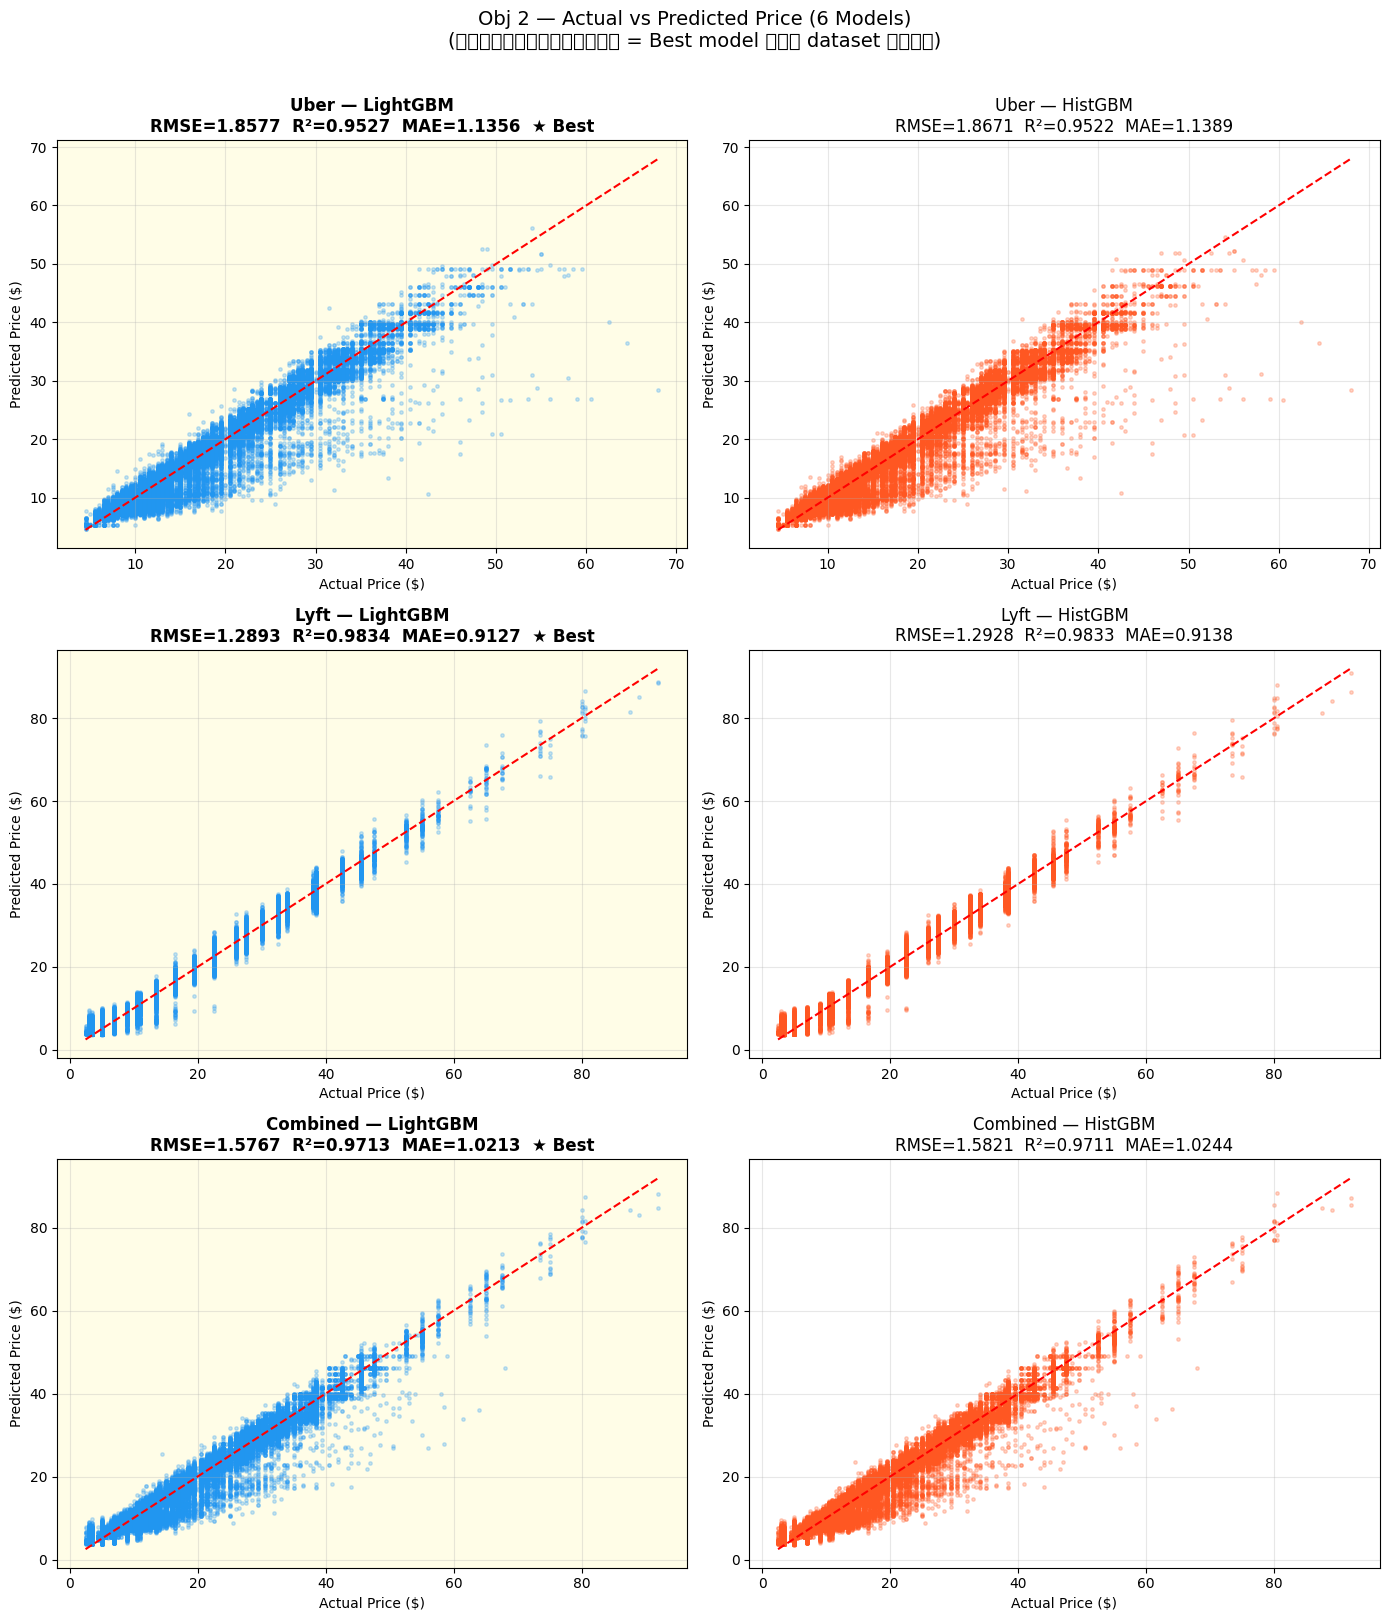

Saved: obj2_actual_vs_predicted.png


In [17]:
# ════════════════════════════════════════════════════════════════
# VISUALIZATION 1: Actual vs Predicted (3 datasets × 2 models)
# — เห็น overall accuracy ของแต่ละ model
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
COLORS = {'LightGBM': '#2196F3', 'HistGBM': '#FF5722'}

for row_i, (ds_name, models) in enumerate(model_results.items()):
    for col_i, (mtype, data) in enumerate(models.items()):
        ax = axes[row_i][col_i]
        y_te   = data['y_te'].values
        y_pred = data['y_pred']

        ax.scatter(y_te, y_pred, alpha=0.25, s=6,
                   color=COLORS[mtype], rasterized=True)
        lim = [y_te.min(), y_te.max()]
        ax.plot(lim, lim, '--r', lw=1.5, label='Perfect prediction')
        ax.set_xlabel('Actual Price ($)')
        ax.set_ylabel('Predicted Price ($)')
        ax.set_title(f'{ds_name} — {mtype}\nRMSE={data["rmse"]:.4f}  R²={data["r2"]:.4f}  MAE={data["mae"]:.4f}')
        ax.grid(alpha=0.3)
        if best_model_names[ds_name] == mtype:
            ax.set_facecolor('#FFFDE7')  # highlight best model
            ax.set_title(ax.get_title() + '  ★ Best', fontweight='bold')

plt.suptitle('Obj 2 — Actual vs Predicted Price (6 Models)\n(พื้นหลังเหลือง = Best model ของ dataset นั้น)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('obj2_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: obj2_actual_vs_predicted.png")

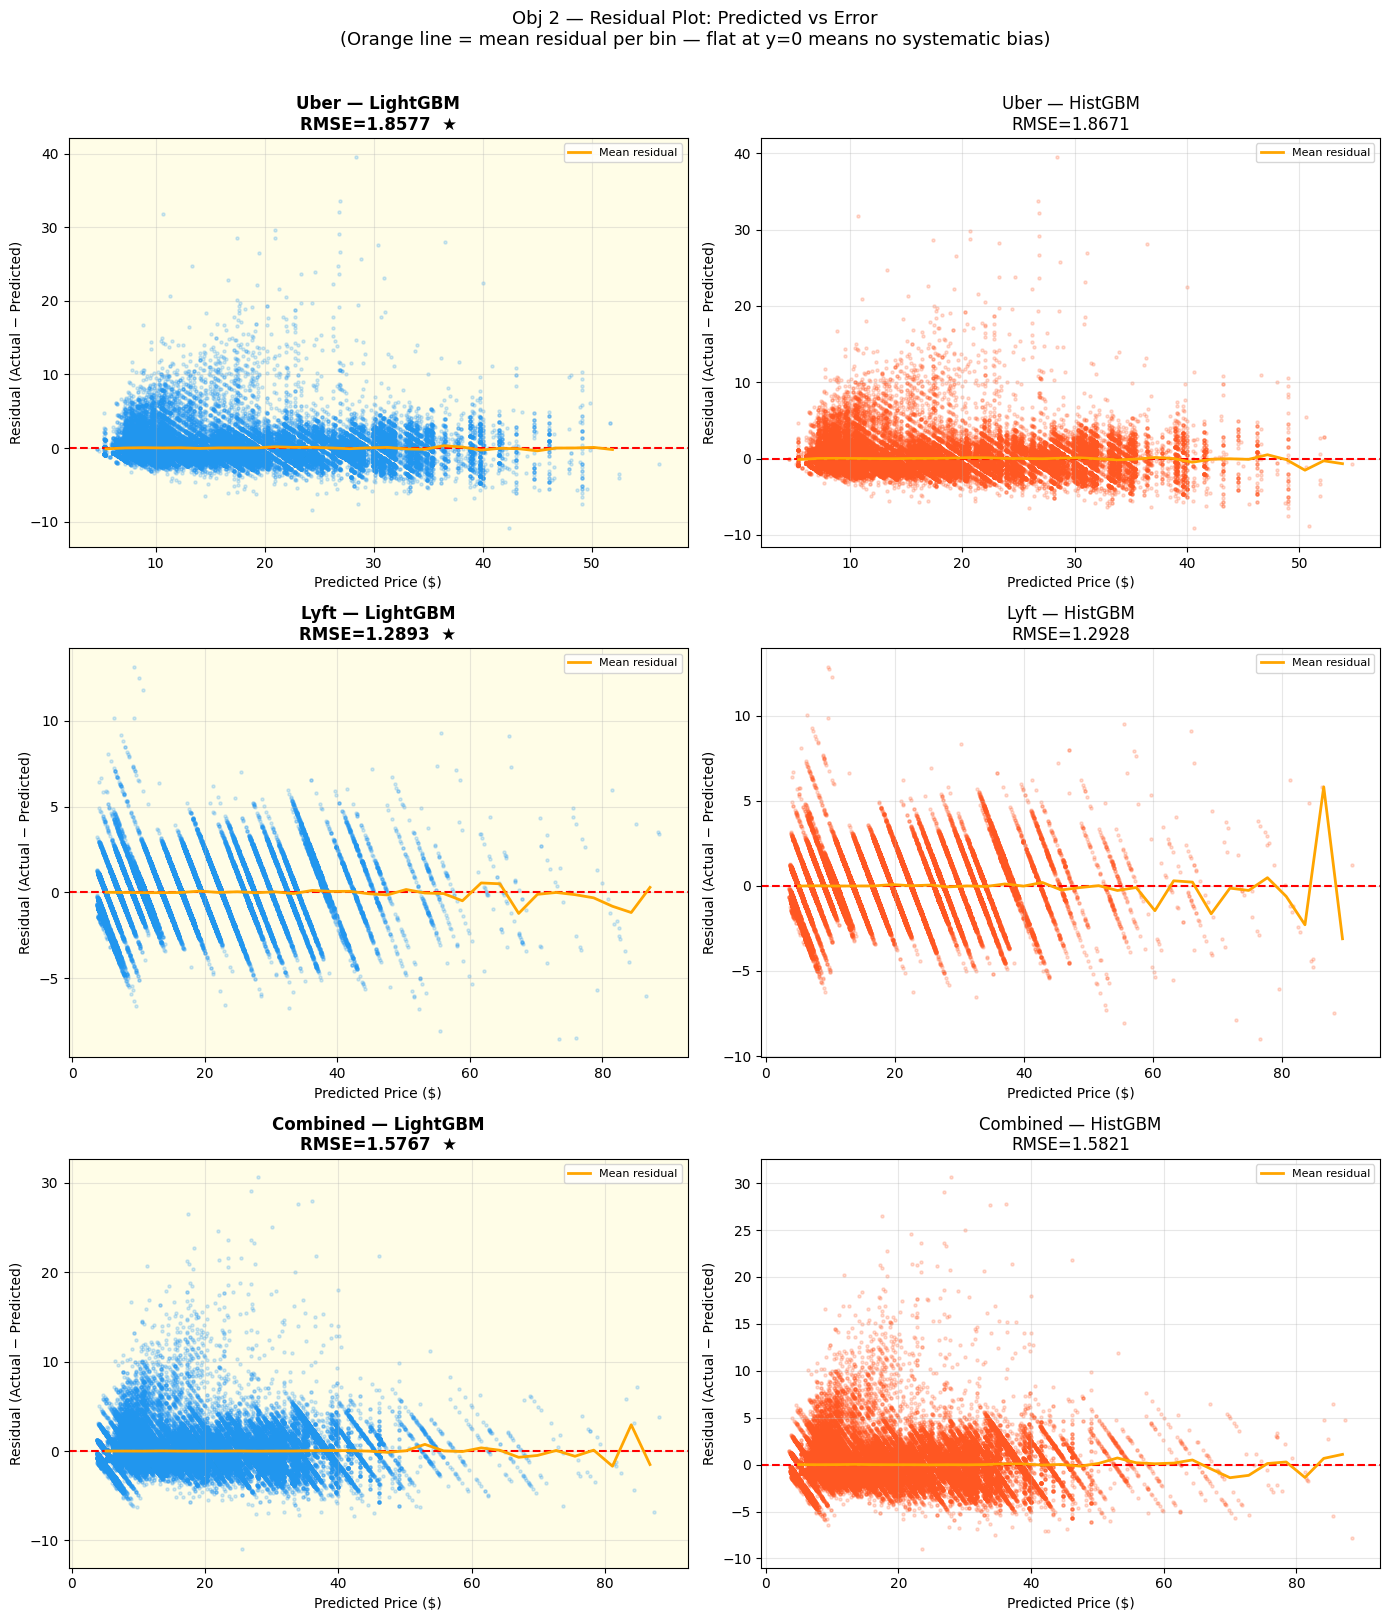

Saved: obj2_residual_plot.png


In [18]:
# ════════════════════════════════════════════════════════════════
# VISUALIZATION 2: Residual Plot (Predicted vs Residual)
# — สำคัญที่สุดใน Obj 2: เห็น pattern ที่ model ยังพลาด
#   ถ้า model ดี → จุดควรกระจายแบบ random รอบ y=0 ไม่มี pattern
#   ถ้าเห็น funnel shape → heteroskedasticity
#   ถ้าเห็น curve → ควร add polynomial feature
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 2, figsize=(14, 16))

for row_i, (ds_name, models) in enumerate(model_results.items()):
    for col_i, (mtype, data) in enumerate(models.items()):
        ax = axes[row_i][col_i]
        y_te      = data['y_te'].values
        y_pred    = data['y_pred']
        residuals = y_te - y_pred

        ax.scatter(y_pred, residuals, alpha=0.2, s=5,
                   color=COLORS[mtype], rasterized=True)
        ax.axhline(0, color='red', lw=1.5, linestyle='--')

        # LOWESS smooth line — เห็น systematic pattern ได้ชัดขึ้น
        from scipy.stats import binned_statistic
        bin_means, bin_edges, _ = binned_statistic(
            y_pred, residuals, statistic='mean', bins=30)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.plot(bin_centers, bin_means, color='orange', lw=2, label='Mean residual')

        ax.set_xlabel('Predicted Price ($)')
        ax.set_ylabel('Residual (Actual − Predicted)')
        ax.set_title(f'{ds_name} — {mtype}\nRMSE={data["rmse"]:.4f}')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        if best_model_names[ds_name] == mtype:
            ax.set_facecolor('#FFFDE7')
            ax.set_title(ax.get_title() + '  ★', fontweight='bold')

plt.suptitle('Obj 2 — Residual Plot: Predicted vs Error\n'
             '(Orange line = mean residual per bin — flat at y=0 means no systematic bias)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('obj2_residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: obj2_residual_plot.png")

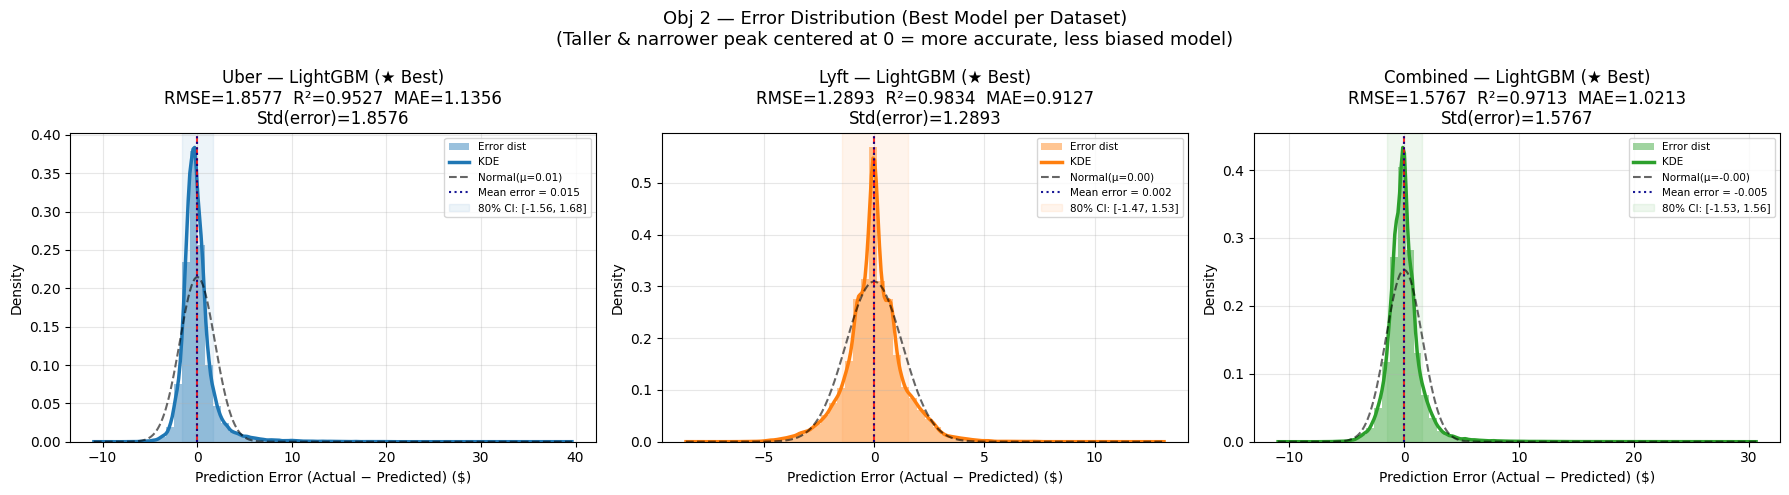

Saved: obj2_error_distribution.png


In [19]:
# ════════════════════════════════════════════════════════════════
# VISUALIZATION 3: Error Distribution (Best models only)
# — shows bias (mean != 0?), symmetry, fat-tail
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ds_list = ['Uber', 'Lyft', 'Combined']
palette = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, ds_name, color in zip(axes, ds_list, palette):
    best_name = best_model_names[ds_name]
    data      = model_results[ds_name][best_name]
    y_te      = data['y_te'].values
    y_pred    = data['y_pred']
    errors    = y_te - y_pred

    # KDE + histogram
    ax.hist(errors, bins=60, density=True, alpha=0.45, color=color, label='Error dist')
    try:
        from scipy.stats import norm, gaussian_kde
        kde = gaussian_kde(errors, bw_method='scott')
        x_range = np.linspace(errors.min(), errors.max(), 300)
        ax.plot(x_range, kde(x_range), color=color, lw=2.5, label='KDE')

        # Normal reference line
        mu, sigma = errors.mean(), errors.std()
        ax.plot(x_range, norm.pdf(x_range, mu, sigma), 'k--', lw=1.5, alpha=0.6, label=f'Normal(μ={mu:.2f})')
    except ImportError:
        pass

    ax.axvline(0, color='red', lw=1.5, linestyle='--', alpha=0.8)
    ax.axvline(errors.mean(), color='darkblue', lw=1.5, linestyle=':', alpha=0.9,
               label=f'Mean error = {errors.mean():.3f}')

    # 80% interval band
    p10, p90 = np.percentile(errors, 10), np.percentile(errors, 90)
    ax.axvspan(p10, p90, alpha=0.08, color=color, label=f'80% CI: [{p10:.2f}, {p90:.2f}]')

    ax.set_xlabel('Prediction Error (Actual − Predicted) ($)')
    ax.set_ylabel('Density')
    ax.set_title(f'{ds_name} — {best_name} (★ Best)\n'
                 f'RMSE={data["rmse"]:.4f}  R²={data["r2"]:.4f}  MAE={data["mae"]:.4f}\n'
                 f'Std(error)={errors.std():.4f}')
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.3)

plt.suptitle('Obj 2 — Error Distribution (Best Model per Dataset)\n'
             '(Taller & narrower peak centered at 0 = more accurate, less biased model)',
             fontsize=13)
plt.tight_layout()
plt.savefig('obj2_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: obj2_error_distribution.png")

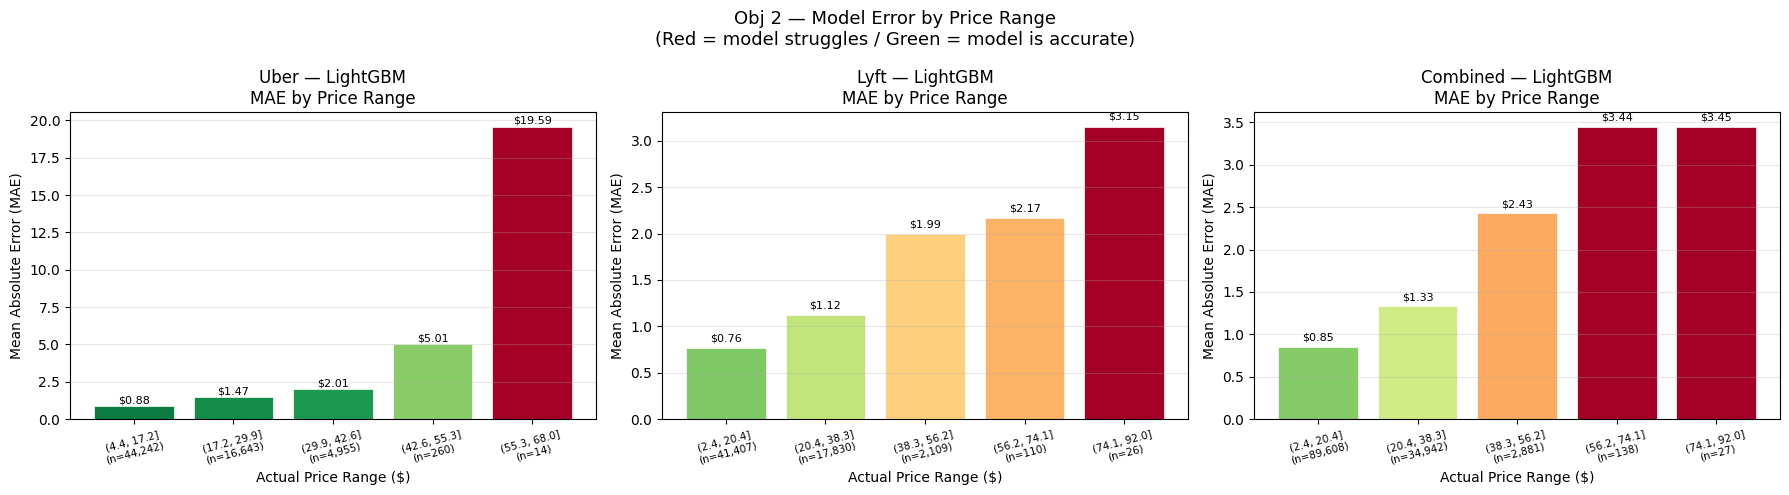

Saved: obj2_error_by_price_range.png


In [20]:
# ════════════════════════════════════════════════════════════════
# VISUALIZATION 4: MAE by Price Range
# — shows where the model struggles: expensive rides harder to predict?
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ds_name, color in zip(axes, ds_list, palette):
    best_name = best_model_names[ds_name]
    data      = model_results[ds_name][best_name]
    y_te      = data['y_te'].values
    y_pred    = data['y_pred']
    abs_err   = np.abs(y_te - y_pred)

    # Split into 5 price bins
    price_bins = pd.cut(y_te, bins=5, precision=1)
    bin_mae    = pd.Series(abs_err).groupby(price_bins).mean()
    bin_count  = pd.Series(abs_err).groupby(price_bins).count()

    bars = ax.bar(
        range(len(bin_mae)),
        bin_mae.values,
        color=[plt.cm.RdYlGn_r(v / bin_mae.max()) for v in bin_mae.values],
        edgecolor='white', linewidth=0.5
    )
    ax.set_xticks(range(len(bin_mae)))
    ax.set_xticklabels(
        [f"{str(b)}\n(n={c:,})" for b, c in zip(bin_mae.index, bin_count.values)],
        fontsize=7.5, rotation=15
    )

    # Label on bar
    for bar, val in zip(bars, bin_mae.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'${val:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xlabel('Actual Price Range ($)')
    ax.set_ylabel('Mean Absolute Error (MAE)')
    ax.set_title(f'{ds_name} — {best_name}\nMAE by Price Range')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Obj 2 — Model Error by Price Range\n'
             '(Red = model struggles / Green = model is accurate)',
             fontsize=13)
plt.tight_layout()
plt.savefig('obj2_error_by_price_range.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: obj2_error_by_price_range.png")

In [21]:
# ════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("Obj 2 — Final Summary: 6 Model Results")
print("="*65)
print(f"{'Dataset':<12} | {'Model':<10} | {'RMSE':>8} | {'R²':>8} | {'MAE':>8} | Status")
print("-"*65)
for ds_name, models in model_results.items():
    for mtype, data in models.items():
        is_best = best_model_names[ds_name] == mtype
        mark    = '★ Best' if is_best else ''
        print(f"{ds_name:<12} | {mtype:<10} | {data['rmse']:>8.4f} | {data['r2']:>8.4f} | {data['mae']:>8.4f} | {mark}")
    print("-"*65)

print("\n📁 Saved visualizations:")
print("  obj2_actual_vs_predicted.png  — Actual vs Predicted (6 models)")
print("  obj2_residual_plot.png        — Residual plot (pattern check)")
print("  obj2_error_distribution.png   — Error distribution (bias check)")
print("  obj2_error_by_price_range.png — MAE by price range (tier insight)")


Obj 2 — Final Summary: 6 Model Results
Dataset      | Model      |     RMSE |       R² |      MAE | Status
-----------------------------------------------------------------
Uber         | LightGBM   |   1.8577 |   0.9527 |   1.1356 | ★ Best
Uber         | HistGBM    |   1.8671 |   0.9522 |   1.1389 | 
-----------------------------------------------------------------
Lyft         | LightGBM   |   1.2893 |   0.9834 |   0.9127 | ★ Best
Lyft         | HistGBM    |   1.2928 |   0.9833 |   0.9138 | 
-----------------------------------------------------------------
Combined     | LightGBM   |   1.5767 |   0.9713 |   1.0213 | ★ Best
Combined     | HistGBM    |   1.5821 |   0.9711 |   1.0244 | 
-----------------------------------------------------------------

📁 Saved visualizations:
  obj2_actual_vs_predicted.png  — Actual vs Predicted (6 models)
  obj2_residual_plot.png        — Residual plot (pattern check)
  obj2_error_distribution.png   — Error distribution (bias check)
  obj2_error_by_pr